In [2]:
import os, random, numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
######## import data 
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [4]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=5000,
    random_state=42,
    stratify=y_train
)





In [5]:
from tensorflow.keras.utils import to_categorical


x_train = x_train.astype('float32') / 255.0
x_val   = x_val.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_val   = to_categorical(y_val, 10)
y_test  = to_categorical(y_test, 10)

In [6]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)


from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=15,        
    width_shift_range=0.1,    
    height_shift_range=0.1,   
    horizontal_flip=True,     
    zoom_range=0.1,           
    fill_mode='nearest'       
)

datagen.fit(x_train)

x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 10)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 10)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 10)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense

def build_cifar_model(
    img_shape=(32, 32, 3),
    num_classes=10,
    dropout_rate=0.4,
    kernel1=(3,3),
    kernel2=(3,3),
    stride1=(1,1),
    stride2=(1,1),
    kernel_init='he_normal'
):
   

    model = Sequential()

    # --- Block 1 ---
    model.add(Conv2D(32, kernel_size=kernel1, strides=stride1,
                     activation='relu', padding='same',
                     kernel_initializer=kernel_init,
                     input_shape=img_shape))
    model.add(BatchNormalization())

    model.add(Conv2D(32, kernel_size=kernel1, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(dropout_rate))

    # --- Block 2 ---
    model.add(Conv2D(64, kernel_size=kernel2, strides=stride2,
                     activation='relu', padding='same'))
    model.add(BatchNormalization())

    model.add(Conv2D(64, kernel_size=kernel2, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(dropout_rate))

    # --- Classifier head ---
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))

    return model

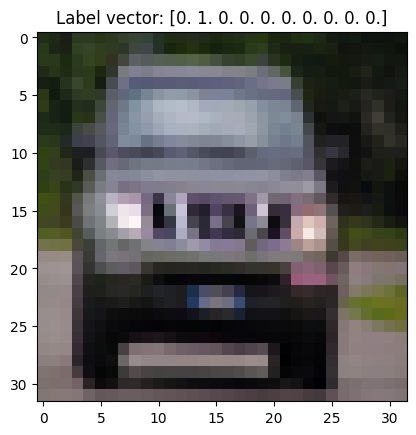

In [8]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
plt.title(f"Label vector: {y_train[0]}")
plt.show()

In [9]:
model1 = build_cifar_model(
    kernel1=(3,3),
    kernel2=(3,3),
    stride1=(1,1),
    stride2=(1,1)
)

model1.summary()

c:\Users\niman\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,042 (2.26 MB)

 Trainable params: 591,658 (2.26 MB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    shuffle=True
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 102ms/step - accuracy: 0.3398 - loss: 1.8217 - val_accuracy: 0.5176 - val_loss: 1.3279
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.4952 - loss: 1.3900 - val_accuracy: 0.6016 - val_loss: 1.1096
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.5827 - loss: 1.1806 - val_accuracy: 0.6592 - val_loss: 0.9885
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy: 0.6303 - loss: 1.0600 - val_accuracy: 0.6930 - val_loss: 0.8595
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.6655 - loss: 0.9710 - val_accuracy: 0.6990 - val_loss: 0.8582
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.6843 - loss: 0.9101 - val_accuracy: 0.7284 - val_loss: 0.7698
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.7011 - loss: 0.8627 - val_accuracy: 0.7380 - val_loss: 0.7549
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.7211 - loss: 0.813

In [11]:
os.makedirs("plots", exist_ok=True)

# ─── 1️ LEARNING CURVES (accuracy + loss) ───────────────────────────
def plot_learning_curves_from_model(model, history, x_test, y_test, tag="cnn"):
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    fig, axs = plt.subplots(2, 1, figsize=(7, 7))
    axs = axs.ravel()

    # Accuracy plot
    axs[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    axs[0].hlines(test_acc, 0, len(history.history['accuracy']),
                  colors='green', label='Test Accuracy')
    axs[0].set_title("Accuracy")
    axs[0].set_xlabel("Iteration")
    axs[0].set_ylabel("Accuracy rate")
    axs[0].legend()

    # Loss plot
    axs[1].plot(history.history['loss'], label='Cross entropy', color='blue')
    axs[1].plot(history.history['val_loss'], label='Val Cross entropy', color='orange')
    axs[1].set_title("Learning Curve")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("Loss")
    axs[1].legend()

    plt.tight_layout()
    file_path = f"plots/learning_curves_{tag}.png"
    plt.savefig(file_path, bbox_inches="tight")
    plt.close()
    print(f" Saved learning curves → {file_path}")


# ─── 2️ WEIGHT HISTOGRAMS ──────────────────────────────────────────
def plot_weight_bias_distributions(model, tag="cnn"):
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
    dense_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Dense)]

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.ravel()

    # conv1
    conv1_w = conv_layers[0].get_weights()[0].ravel()
    axs[0].hist(conv1_w, bins=80, color='steelblue')
    axs[0].set_title('Histogram of conv1')
    axs[0].set_xlabel('Value'); axs[0].set_ylabel('Number')

    # conv2
    if len(conv_layers) > 1:
        conv2_w = conv_layers[1].get_weights()[0].ravel()
        axs[1].hist(conv2_w, bins=80, color='steelblue')
        axs[1].set_title('Histogram of conv2')
        axs[1].set_xlabel('Value'); axs[1].set_ylabel('Number')

    # dense1
    dense1_w = dense_layers[0].get_weights()[0].ravel()
    axs[2].hist(dense1_w, bins=80, color='steelblue')
    axs[2].set_title('Histogram of dense1')
    axs[2].set_xlabel('Value'); axs[2].set_ylabel('Number')

    # output
    dense_out_w = dense_layers[-1].get_weights()[0].ravel()
    axs[3].hist(dense_out_w, bins=80, color='steelblue')
    axs[3].set_title('Histogram of output')
    axs[3].set_xlabel('Value'); axs[3].set_ylabel('Number')

    plt.tight_layout()
    file_path = f"plots/weights_hist_{tag}.png"
    plt.savefig(file_path, bbox_inches="tight")
    plt.close()
    print(f" Saved weight histograms → {file_path}")




def plot_bias_distributions(model, tag="cnn"):

  
    # Collect all layers with biases
    layers_with_bias = [
        l for l in model.layers
        if hasattr(l, "get_weights") and len(l.get_weights()) > 1
    ]

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.ravel()
    count = 0

    for layer in layers_with_bias:
        if count >= 4:
            break
        # Some layers may not have biases (BatchNorm etc.)
        weights = layer.get_weights()
        if len(weights) < 2:
            continue
        bias = weights[1].ravel()
        axs[count].hist(bias, bins=80, color='orange', alpha=0.8)
        axs[count].set_title(f"Histogram of bias: {layer.name}")
        axs[count].set_xlabel("Value")
        axs[count].set_ylabel("Number")
        count += 1

    # If fewer than 4 layers have biases, hide empty plots
    for i in range(count, 4):
        axs[i].axis("off")

    plt.tight_layout()
    file_path = f"plots/bias_hist_{tag}.png"
    plt.savefig(file_path, bbox_inches="tight")
    plt.close()
    print(f" Saved bias histograms → {file_path}")

In [12]:
plot_learning_curves_from_model(model1, history1, x_test, y_test, tag="cifar_model1")
plot_weight_bias_distributions(model1, tag="cifar_model1")
plot_bias_distributions(model1, tag="cifar_model1")


 Saved learning curves → plots/learning_curves_cifar_model1.png
 Saved weight histograms → plots/weights_hist_cifar_model1.png
 Saved bias histograms → plots/bias_hist_cifar_model1.png


In [13]:
### model 2 with 5,5 filter and 2,2 stride


model2 = build_cifar_model(
    kernel1=(5,5),
    kernel2=(5,5),
    stride1=(2,2),
    stride2=(2,2)
)
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    shuffle=True
)

c:\Users\niman\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 83ms/step - accuracy: 0.3318 - loss: 1.8341 - val_accuracy: 0.4440 - val_loss: 1.5182
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.4766 - loss: 1.4435 - val_accuracy: 0.5208 - val_loss: 1.2761
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5452 - loss: 1.2703 - val_accuracy: 0.5748 - val_loss: 1.2349
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5905 - loss: 1.1565 - val_accuracy: 0.6336 - val_loss: 1.0260
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6191 - loss: 1.0731 - val_accuracy: 0.6612 - val_loss: 0.9508
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6429 - loss: 1.0093 - val_accuracy: 0.6674 - val_loss: 0.9263
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6637 - loss: 0.9528 - val_accuracy: 0.6446 - val_loss: 1.0005
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6785 - loss: 0.9164 - 

In [14]:
plot_learning_curves_from_model(model2, history2, x_test, y_test, tag="cifar_model2")
plot_weight_bias_distributions(model2, tag="cifar_model2")
plot_bias_distributions(model2, tag="cifar_model2")

 Saved learning curves → plots/learning_curves_cifar_model2.png
 Saved weight histograms → plots/weights_hist_cifar_model2.png
 Saved bias histograms → plots/bias_hist_cifar_model2.png


In [15]:
###### Model 3 with filter 7,7 and stride 1,1
model3 = build_cifar_model(
    kernel1=(7,7),
    kernel2=(7,7),
    stride1=(1,1),
    stride2=(1,1)
)
model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    shuffle=True
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 227ms/step - accuracy: 0.3562 - loss: 1.7783 - val_accuracy: 0.4098 - val_loss: 1.5561
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 133s 188ms/step - accuracy: 0.5166 - loss: 1.3531 - val_accuracy: 0.5996 - val_loss: 1.1006
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 170s 241ms/step - accuracy: 0.5984 - loss: 1.1491 - val_accuracy: 0.6636 - val_loss: 0.9661
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 199s 283ms/step - accuracy: 0.6476 - loss: 1.0192 - val_accuracy: 0.6780 - val_loss: 0.9361
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 341s 484ms/step - accuracy: 0.6794 - loss: 0.9323 - val_accuracy: 0.7080 - val_loss: 0.8464
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 288ms/step - accuracy: 0.7056 - loss: 0.8541 - val_accuracy: 0.7134 - val_loss: 0.8427
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 143ms/step - accuracy: 0.7242 - loss: 0.8085 - val_accuracy: 0.7508 - val_loss: 0.7151
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 144ms/step - accuracy: 0.7444 -

In [16]:
plot_learning_curves_from_model(model3, history3, x_test, y_test, tag="cifar_model3")
plot_weight_bias_distributions(model3, tag="cifar_model3")
plot_bias_distributions(model3, tag="cifar_model3")

 Saved learning curves → plots/learning_curves_cifar_model3.png
 Saved weight histograms → plots/weights_hist_cifar_model3.png
 Saved bias histograms → plots/bias_hist_cifar_model3.png


In [17]:
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense

def build_cnn_model_L2(
    img_rows=32, img_cols=32,
    num_classes=10,
    dropout_rate=0.4,
    kernel_init='he_normal',
    l2_lambda=0.001,             
    kernel1=(7,7),
    kernel2=(7,7),
    stride1=(1,1),
    stride2=(1,1)
):
    model = Sequential()

    # --- Block 1 ---
    model.add(Conv2D(32, kernel_size=kernel1, activation='relu',
                     padding="same", kernel_initializer=kernel_init,
                     kernel_regularizer=regularizers.l2(l2_lambda),
                     input_shape=(img_rows, img_cols, 3)))   
    model.add(BatchNormalization())

    model.add(Conv2D(32, kernel_size=kernel2, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(dropout_rate))

    # --- Block 2 ---
    model.add(Conv2D(64, kernel_size=kernel2, strides=stride1,
                     padding='same', activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(dropout_rate))

    # --- Classifier ---
    model.add(Flatten())
    model.add(Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_lambda)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax',
                    kernel_regularizer=regularizers.l2(l2_lambda)))

    return model


In [19]:
model_L2 = build_cnn_model_L2(l2_lambda=0.001)
model_L2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_L2 = model_L2.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 60s 162ms/step - accuracy: 0.3461 - loss: 2.2075 - val_accuracy: 0.3986 - val_loss: 2.1220
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 57s 161ms/step - accuracy: 0.4784 - loss: 1.7844 - val_accuracy: 0.5100 - val_loss: 1.7273
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.5578 - loss: 1.5550 - val_accuracy: 0.4946 - val_loss: 1.8756
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.6132 - loss: 1.4097 - val_accuracy: 0.5580 - val_loss: 1.5912
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.6479 - loss: 1.3117 - val_accuracy: 0.6170 - val_loss: 1.4383
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 57s 161ms/step - accuracy: 0.6699 - loss: 1.2631 - val_accuracy: 0.6792 - val_loss: 1.2347
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.6854 - loss: 1.2237 - val_accuracy: 0.7016 - val_loss: 1.1500
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 57s 161ms/step - accuracy: 0.6986 - loss: 1

In [20]:
plot_learning_curves_from_model(model_L2, history_L2, x_test, y_test, tag="L2_0p001")
plot_weight_bias_distributions(model_L2, tag="L2_0p001")
plot_bias_distributions(model_L2, tag="L2_0p001")

 Saved learning curves → plots/learning_curves_L2_0p001.png
 Saved weight histograms → plots/weights_hist_L2_0p001.png
 Saved bias histograms → plots/bias_hist_L2_0p001.png


In [22]:
import os
import matplotlib.pyplot as plt
import numpy as np

# ---- Predictions ----
y_pred_probs = model_L2.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] == 10:
    y_test_classes = np.argmax(y_test, axis=1)
else:
    y_test_classes = y_test

#  Correctness checks
correct_idx = np.where(y_pred == y_test_classes)[0]
incorrect_idx = np.where(y_pred != y_test_classes)[0]

print(f"Correctly classified: {len(correct_idx)}")
print(f"Misclassified: {len(incorrect_idx)}")


# ---- Function to visualize ----
def plot_predictions(x_data, y_true, y_pred, correct_idx, incorrect_idx,
                     n_show=8, tag="cifar_L2", save=True, show=True):

    os.makedirs("plots", exist_ok=True)
    plt.figure(figsize=(14, 6))

    # --- Correctly classified ---
    for i, idx in enumerate(correct_idx[:n_show]):
        plt.subplot(2, n_show, i+1)
        img = x_data[idx]
        if img.shape[-1] == 1:
            plt.imshow(img.reshape(img.shape[0], img.shape[1]), cmap='gray')
        else:
            plt.imshow(img)
        plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
        plt.axis('off')

    # --- Misclassified ---
    for i, idx in enumerate(incorrect_idx[:n_show]):
        plt.subplot(2, n_show, i+1+n_show)
        img = x_data[idx]
        if img.shape[-1] == 1:
            plt.imshow(img.reshape(img.shape[0], img.shape[1]), cmap='gray')
        else:
            plt.imshow(img)
        plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
        plt.axis('off')

    plt.suptitle("Top: Correctly Classified | Bottom: Misclassified", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)

    if save:
        file_path = f"plots/predictions_{tag}.png"
        plt.savefig(file_path, bbox_inches="tight")
        print(f"💾 Saved predictions plot → {file_path}")

    if show:
        plt.show()

    plt.close()


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Correctly classified: 7182
Misclassified: 2818


💾 Saved predictions plot → plots/predictions_cifar10_L2_0p001.png


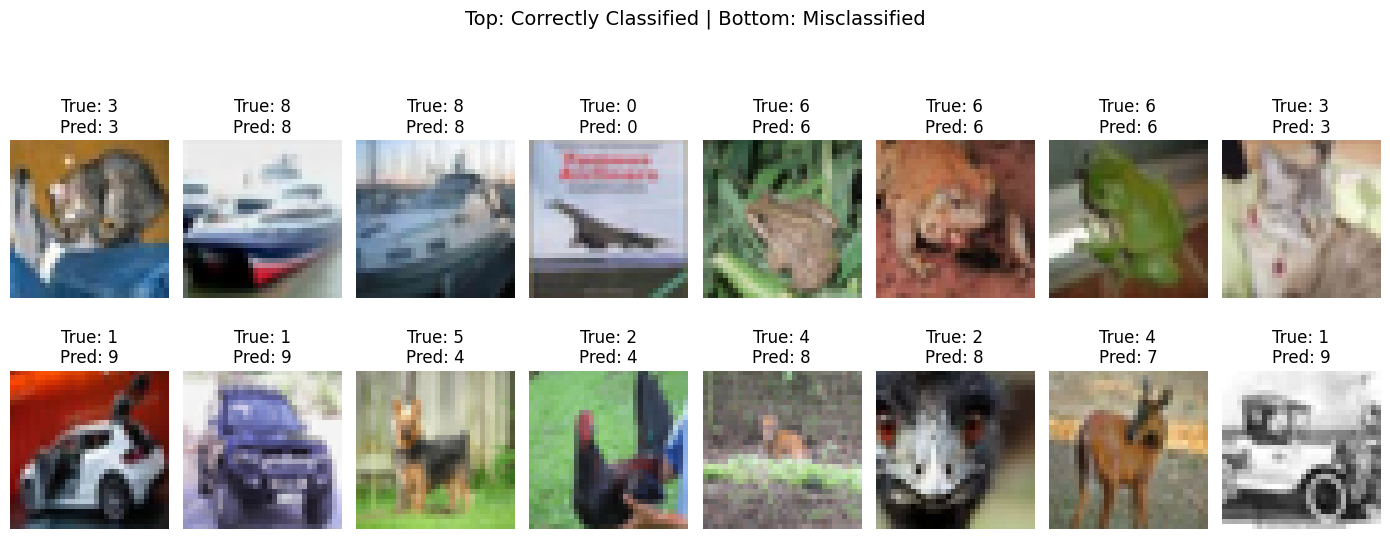

In [23]:
plot_predictions(x_test, y_test_classes, y_pred,
                 correct_idx, incorrect_idx,
                 n_show=8, tag="cifar10_L2_0p001",
                 save=True, show=True)


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

def visualize_feature_maps(model, x_sample, tag="featuremap", max_channels=8):
    os.makedirs("plots", exist_ok=True)

    # Ensure batch dimension
    if x_sample.ndim == 3:
        x_sample = np.expand_dims(x_sample, axis=0)
    x_sample = x_sample.astype("float32")

    #  Run one forward pass to activate all layers
    _ = model(x_sample, training=False)

    # Collect Conv2D layers
    conv_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    if not conv_layers:
        print("⚠️ No Conv2D layers found.")
        return

    #  Directly compute activations in eager mode
    activations = []
    x = x_sample
    for layer in model.layers:
        x = layer(x, training=False)
        if isinstance(layer, tf.keras.layers.Conv2D):
            activations.append((layer.name, x.numpy()))

    #  Plot and save
    for layer_name, fmap in activations:
        n_features = fmap.shape[-1]
        n_display = min(max_channels, n_features)

        fig, axes = plt.subplots(1, n_display, figsize=(n_display * 1.5, 2))
        fig.suptitle(f"Feature maps: {layer_name}", fontsize=13)

        for i in range(n_display):
            ax = axes[i] if n_display > 1 else axes
            ax.imshow(fmap[0, :, :, i], cmap="viridis")
            ax.axis("off")

        plt.tight_layout()
        plt.subplots_adjust(top=0.8)
        file_path = f"plots/featuremaps_{layer_name}_{tag}.png"
        plt.savefig(file_path, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"💾 Saved feature maps → {file_path}")


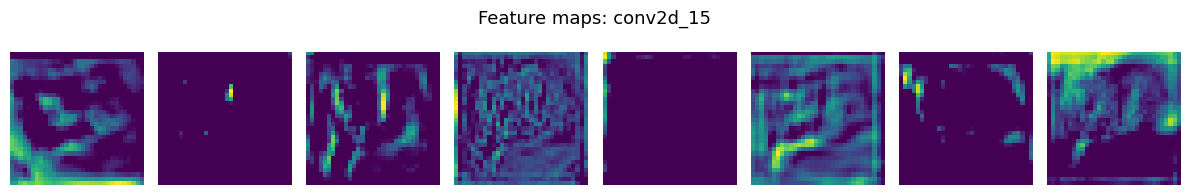

💾 Saved feature maps → plots/featuremaps_conv2d_15_cifar10_L2_0p001.png


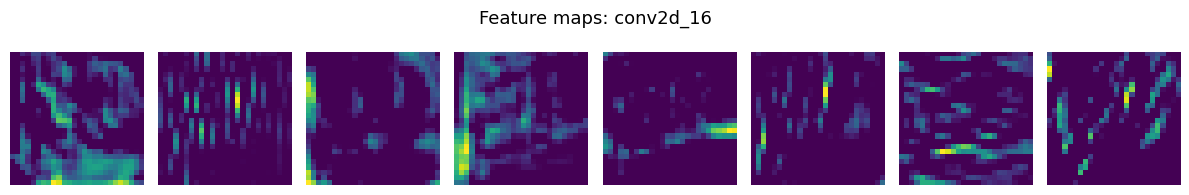

💾 Saved feature maps → plots/featuremaps_conv2d_16_cifar10_L2_0p001.png


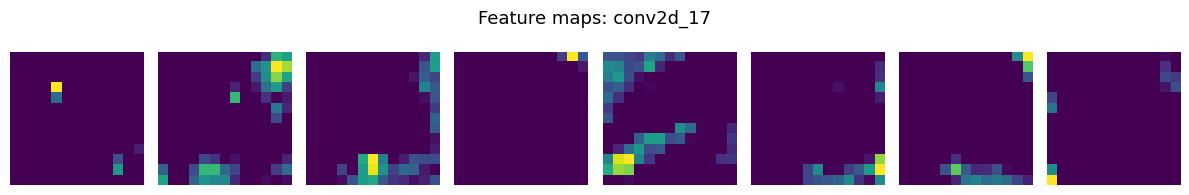

💾 Saved feature maps → plots/featuremaps_conv2d_17_cifar10_L2_0p001.png


In [39]:
sample_img = x_test[correct_idx[0]]
visualize_feature_maps(model_L2, sample_img, tag="cifar10_L2_0p001")
